Parámetros (espacio normalizado): w = 1.025271, b = 0.042424
MSE final (normalizado): 6.962539e-03 | iteraciones: 2273
Parámetros en ESCALA ORIGINAL: w_raw = 0.000126, b_raw = 144.153258


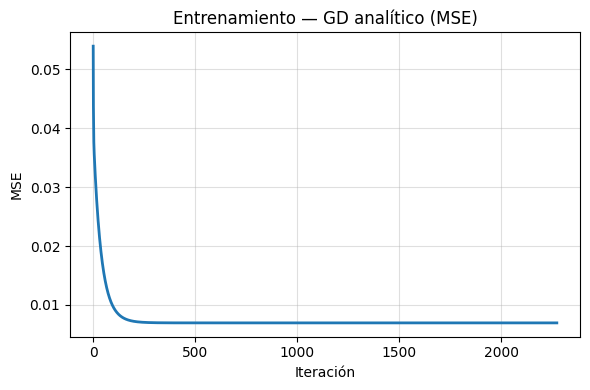

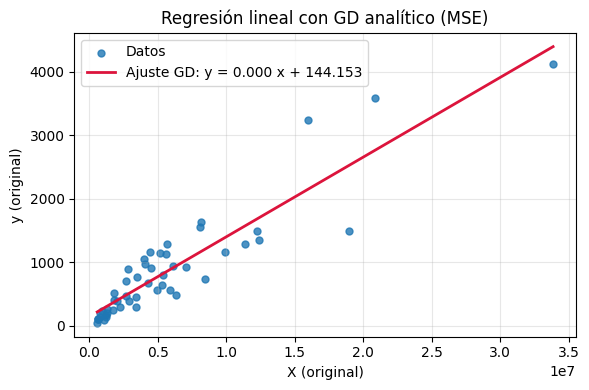

In [1]:
# ==========================================================
# Práctica 6: Regresión lineal (MSE) con Gradiente Analítico
# Dataset: DatosPractica1CLuna.csv
# Nota mental (ejemplo de las llaves):
# - Quiero encontrar mis llaves en una casa. El "error" es qué tan lejos estoy.
# - El gradiente me dice hacia dónde bajar más rápido (dirección de menor error).
# - El learning rate es el tamaño de paso que doy dentro de la casa.
# - Normalizar es "acomodar la casa" para moverme sin tropezarme.
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 1) Carga del dataset
#    (X = 1a columna, y = 2a columna)
# -----------------------
url = "https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/DatosPractica1CLuna.csv"
df = pd.read_csv(url)

X_raw = df.iloc[:, 0].astype(float).values
y_raw = df.iloc[:, 1].astype(float).values
n = X_raw.size

# ---------------------------------------------------------
# 2) Normalización min-max
#    (acomodo la casa para poder buscar mejor)
# ---------------------------------------------------------
Xmin, Xmax = X_raw.min(), X_raw.max()
ymin, ymax = y_raw.min(), y_raw.max()

# Evito divisiones entre cero con un epsilon chiquito
eps = 1e-12
X = (X_raw - Xmin) / (Xmax - Xmin + eps)
y = (y_raw - ymin) / (ymax - ymin + eps)

# -----------------------------------------
# 3) MSE y su gradiente ANALÍTICO
#    MSE(w,b) = (1/n) * sum( (y - (w*x + b))^2 )
#    dMSE/dw  = (2/n) * sum( (w*x + b - y) * x )
#    dMSE/db  = (2/n) * sum( (w*x + b - y) )
#    (aquí "derivé" la fórmula:)
# -----------------------------------------
def mse(w, b, X, y):
    yhat = w * X + b
    return float(np.mean((y - yhat) ** 2))

def grad_mse(w, b, X, y):
    yhat = w * X + b
    err = (yhat - y)           # "qué tan lejos estoy de las llaves" por punto
    gw = (2.0 / X.size) * np.dot(err, X)   # pendiente w
    gb = (2.0 / X.size) * np.sum(err)      # intercepto b
    return gw, gb

# -------------------------------
# 4) Gradiente Descendente (GD)
#    (voy dando pasitos hacia donde baja el error)
# -------------------------------
w, b = 0.0, 0.0        # arranco en cero (estoy parado en la entrada de la casa)
lr0 = 0.2              # tamaño de paso inicial (paso "grande", pero no exagerado)
decay = 1e-3           # poco a poco hago pasos más cortos (ya me acerco a las llaves)
max_iter = 5000

hist = []              # guardo el MSE de cada vuelta para graficar
for t in range(1, max_iter + 1):
    # Saco la dirección correcta (gradiente analítico)
    gw, gb = grad_mse(w, b, X, y)

    # Ajusto el paso: al inicio avanzo más, al final más finito
    lr = lr0 / (1.0 + decay * t)

    # Actualizo mis "pasos" (w,b) en sentido contrario al gradiente
    w -= lr * gw
    b -= lr * gb

    # Guardo el error de esta iteración
    hist.append(mse(w, b, X, y))

    # Si el gradiente ya es chiquitito, ya no tiene caso seguir (ya “encontré”)
    if np.hypot(gw, gb) < 1e-8:
        break

print(f"Parámetros (espacio normalizado): w = {w:.6f}, b = {b:.6f}")
print(f"MSE final (normalizado): {hist[-1]:.6e} | iteraciones: {len(hist)}")

# ---------------------------------------------------------
# 5) Pasar el modelo a la ESCALA ORIGINAL
#    (para dibujar la recta sobre los datos originales)
#    y = ymin + (ymax - ymin) * [ w*(X_raw - Xmin)/(Xmax - Xmin) + b ]
#    => w_raw = (ymax - ymin)/(Xmax - Xmin) * w
#       b_raw = ymin + (ymax - ymin)*b - w_raw*Xmin
# ---------------------------------------------------------
scale_x = (Xmax - Xmin + eps)
scale_y = (ymax - ymin + eps)
w_raw = (scale_y / scale_x) * w
b_raw = ymin + scale_y * b - w_raw * Xmin
print(f"Parámetros en ESCALA ORIGINAL: w_raw = {w_raw:.6f}, b_raw = {b_raw:.6f}")

# -----------------------------------------
# 6) Curva de entrenamiento (MSE vs iter)
#    (debería verse que baja rápido y luego se estabiliza)
# -----------------------------------------
plt.figure(figsize=(6,4))
plt.plot(hist, lw=2)
plt.xlabel("Iteración")
plt.ylabel("MSE")
plt.title("Entrenamiento — GD analítico (MSE)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# -----------------------------------------
# 7) Visualizar el ajuste en ESCALA ORIGINAL
#    (nube de puntos + recta aprendida)
# -----------------------------------------
yhat_raw = w_raw * X_raw + b_raw
order = np.argsort(X_raw)

plt.figure(figsize=(6,4))
plt.scatter(X_raw, y_raw, s=25, color="tab:blue", alpha=0.8, label="Datos")
plt.plot(X_raw[order], yhat_raw[order], color="crimson", lw=2,
         label=f"Ajuste GD: y = {w_raw:.3f} x + {b_raw:.3f}")
plt.xlabel("X (original)")
plt.ylabel("y (original)")
plt.title("Regresión lineal con GD analítico (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
